# Warm-Glow Bequest Motive and Portfolio Choice

The `BequestWarmGlowPortfolioType` extends `BequestWarmGlowConsumerType` to include portfolio allocation between a risky and riskless asset. Because the model combines two others in HARK, the details of the solution methods are not extensively covered here. Please see our other notebooks on [bequest motives](BequestWarmGlowConsumerType.ipynb) and [portfolio allocation](../ConsPortfolioModel/RiskyAssetConsumerType.ipynb).

In [1]:
# Initial imports and setup
from time import time
import numpy as np
import matplotlib.pyplot as plt

from HARK.Calibration.Income.IncomeTools import (
    Cagetti_income,
    parse_income_spec,
    parse_time_params,
)
from HARK.Calibration.life_tables.us_ssa.SSATools import parse_ssa_life_table
from HARK.models import BequestWarmGlowPortfolioType, PortfolioConsumerType
from HARK.ConsumptionSaving.ConsBequestModel import init_portfolio_bequest

mystr = lambda number: f"{number:.4f}"

## Warm Glow Bequest with Portfolio Allocation Model Statement

Each period, a `BequestWarmGlowPortfolioType` chooses how much to consume vs save in assets, and how to divide their wealth between a risky and riskless asset. They receive flow utility from consumption according to a CRRA function, and also have a "warm glow" bequest motive that yields additional utility at their passing.

$\newcommand{\CRRA}{\rho}$
$\newcommand{\LivPrb}{\mathsf{S}}$
$\newcommand{\DiscFac}{\beta}$
$\newcommand{\PermGroFac}{\Gamma}$
$\newcommand{\Rfree}{\mathsf{R}}$
$\newcommand{\Risky}{\mathfrak{R}}$
$\newcommand{\BeqShift}{\xi}$
$\newcommand{\BeqFac}{\alpha}$

The model can be written in Bellman form as:

\begin{align*}
\text{v}_t(m_t) &= \max_{c_t, s_t} \frac{c_t^{1-\CRRA}}{1-\CRRA} + \LivPrb_t \DiscFac \mathbb{E} \left[ (\PermGroFac_{t+1} \psi_{t+1})^{1-\CRRA}\text{v}_{t+1}(m_{t+1}) \right] + (1-\LivPrb_t) \BeqFac \frac{(a_t + \BeqShift)^{1-\CRRA}}{1-\CRRA} \\
&\text{s.t.} \\
a_t &= m_t - c_t, \\
a_t &\geq 0, \\
s_t &\in [0,1], \\
m_{t+1} &= a_t R_{t+1}/(\PermGroFac_{t+1} \psi_{t+1}) + \theta_{t+1}, \\
R_{t+1} &= s_t \Risky_{t+1} + (1-s_t) \Rfree_{t+1}, \\
(\psi_{t+1},\theta_{t+1}) &\sim F_{t+1}, \\
\Risky_{t+1} &\sim G, \\
\mathbb{E}[\psi] &= 1. \\
\end{align*}

The model is identical to that of the standard `RiskyAssetConsumerType` but for the addition of the bequest motive term.

## Example Parameters for `BequestWarmGlowPortfolioType`

The default parameters for `BequestWarmGlowPortfolioType` combine those of `BequestWarmGlowConsumerType` and `PortfolioConsumerType`. Thus the ["advanced options"](../ConsPortfolioModel/PortfolioConsumerType.ipynb) for portfolio models are available in this model.

| Parameter | Description | Code | Example value | Time-varying? |
| :---: | --- | --- | --- | --- |
| $\DiscFac$ |Intertemporal discount factor  | `DiscFac` | $0.96$ |  |
| $\CRRA$ |Coefficient of relative risk aversion | `CRRA` | $2.0$ | |
| $\Rfree_t$ | Risk free interest factor | `Rfree` | $[1.03]$ | $\surd$ |
| $\gamma$ | Marginal propensity to consume in terminal period | `BeqMPC`| $0.2$ |  |
| $\kappa$ | Consumption function intercept term in terminal period | `BeqInt`| $0.1$ |  |
| $\mu_\Risky$ | Mean risky asset return | `RiskyAvg` | $1.08$ | |
| $\sigma_\Risky$ | Standard deviation of log risky asset return | `RiskyStd` | $0.18$ | |
| $N_\Risky$ | Number of equiprobable nodes in risky asset return distribution | `RiskyCount` | $5$ | |
| $\LivPrb_t$ |Survival probability | `LivPrb` | $[0.98]$ | $\surd$ |
| $\PermGroFac_{t}$ |Permanent income growth factor| `PermGroFac` | $[1.01]$ | $\surd$ |
| $\sigma_\psi$ | Standard deviation of log permanent income shocks | `PermShkStd` | $[0.1]$ |$\surd$ |
| $N_\psi$ | Number of discrete permanent income shocks | `PermShkCount` | $7$ | |
| $\sigma_\theta$ | Standard deviation of log transitory income shocks | `TranShkStd` | $[0.1]$ | $\surd$ |
| $N_\theta$| Number of discrete transitory income shocks | `TranShkCount` | $7$ |  |
| $\mho$ | Probability of being unemployed and getting $\theta=\underline{\theta}$ | `UnempPrb` | $0.05$ |  |
| $\underline{\theta}$| Transitory shock when unemployed | `IncUnemp` | $0.3$ |  |
| $\mho^{Ret}$ | Probability of being "unemployed" when retired | `UnempPrbRet` | $0.0005$ |  |
| $\underline{\theta}^{Ret}$| Transitory shock when "unemployed" and retired | `IncUnempRet` | $0.0$ |  |
| $(none)$ | Period of the lifecycle model when retirement begins | `T_retire` | $0$ | |
| $(none)$ | Minimum value in assets-above-minimum grid | `aXtraMin` | $0.001$ | |
| $(none)$ | Maximum value in assets-above-minimum grid | `aXtraMax` | $20.0$ | |
| $(none)$ | Number of points in base assets-above-minimum grid | `aXtraCount` | $48$ | |
| $(none)$ | Exponential nesting factor for base assets-above-minimum grid | `aXtraNestFac` | $3$ | |
| $(none)$ | Additional values to add to assets-above-minimum grid | `aXtraExtra` | $None$ | |
| $K$ | Number of discrete points in risky share grid | `ShareCount` | $25$ | |
| $L$ | Number of times to perform an "augmented" risky share search | `ShareAugFac` | $0$ | |
| $(none)$ | Fixed risky asset share, disallowing portfolio choice | `RiskyShareFixed` | $1.0$ | |
| $(none)$ | Indicator for whether `vFunc` should be computed | `vFuncBool` | $False$ | |
| $(none)$ | Indicator for whether `cFunc` should use cubic splines | `CubicBool` | $False$ |  |
| $(none)$ | Indicator for whether $F_t$ and $G$ are independent | `IndepDstnBool` | $True$ |  |

## Example Implementation of `BequestWarmGlowPortfolioType`

Just like `BequestWarmGlowConsumerType`, this model produces more interesting results in a life-cycle setting than for infinite horizon, so let's specify reasonably plausible parameters in a dictionary.

In [2]:
# Define a life-cycle calibration using HARK tools
birth_age = 22
death_age = 110
adjust_infl_to = 1992
income_calib = Cagetti_income["College"]
income_calib["PermShkStd"] = 0.1
income_calib["TranShkStd"] = 0.1

# Income specification
income_params = parse_income_spec(
    age_min=birth_age,
    age_max=death_age,
    adjust_infl_to=adjust_infl_to,
    **income_calib,
)

# Survival and time specification
liv_prb = parse_ssa_life_table(
    female=False, cross_sec=True, year=2004, age_min=birth_age, age_max=death_age
)
time_params = parse_time_params(age_birth=birth_age, age_death=death_age)

# Put it all together into a dictionary
lifecycle_dict = income_params.copy()
lifecycle_dict["LivPrb"] = liv_prb
lifecycle_dict.update(**time_params)
lifecycle_dict["Rfree"] = lifecycle_dict["T_cycle"] * [1.01]
lifecycle_dict["Risky"] = 1.04
lifecycle_dict["T_sim"] = 80
lifecycle_dict["seed"] = 0
lifecycle_dict["CRRA"] = 5.0

In [3]:
# Combine the life-cycle parameters with the default parameters for the bequest motive model
my_params = init_portfolio_bequest.copy()
my_params.update(lifecycle_dict)
del my_params["constructors"]  # don't overwrite

We'll use the portfolio allocation model without a bequest motive as a baseline comparison. Note that we're giving `PortfolioConsumerType` bequest motive parameters, but they will be *ignored*.

In [4]:
# Make and solve a baseline consumer type
BaseType = PortfolioConsumerType(**my_params)
t0 = time()
BaseType.solve()
t1 = time()
print("Solving the baseline consumer's problem took " + mystr(t1 - t0) + " seconds.")

Solving the baseline consumer's problem took 2.3366 seconds.


Just like in the bequest model without portfolio allocation, the bequest motive will make the agents want to hold more wealth, so we'll make *two* versions with a bequest motive. The first will have the same discount factor $\DiscFac$ as our baseline agents, and the other will be significantly more impatient ($\DiscFac = 0.925$). The latter type's discount factor is (roughly) calibrated so that their wealth at retirement is similar to the baseline type's.

In [5]:
# Make and solve a consumer with a bequest motive
BequestType = BequestWarmGlowPortfolioType(**my_params)
t0 = time()
BequestType.solve()
t1 = time()
print("Solving the bequest consumer's problem took " + mystr(t1 - t0) + " seconds.")

Solving the bequest consumer's problem took 2.2880 seconds.


In [6]:
# Make and solve a consumer with a bequest motive who is more impatient
ImpatientType = BequestWarmGlowPortfolioType(**my_params)
ImpatientType.DiscFac = 0.925
t0 = time()
ImpatientType.solve()
t1 = time()
print("Solving the impatient consumer's problem took " + mystr(t1 - t0) + " seconds.")

Solving the impatient consumer's problem took 2.4043 seconds.


Now we can simulate all types' model and plot the trajectory of wealth over their lifecycle.

In [7]:
# Simulate all types' models, following one cohort without death
t0 = time()
BaseType.initialize_sym(stop_dead=False)
BaseType.symulate()
BequestType.initialize_sym(stop_dead=False)
BequestType.symulate()
ImpatientType.initialize_sym(stop_dead=False)
ImpatientType.symulate()
t1 = time()
print("Simulating all types took " + mystr(t1 - t0) + " seconds.")

Simulating all types took 3.9109 seconds.


In [8]:
# Extract mean wealth profiles for all types
aLvl_base = BaseType.hystory["aNrm"] * BaseType.hystory["pLvl"]
aLvl_bequest = BequestType.hystory["aNrm"] * BequestType.hystory["pLvl"]
aLvl_impatient = ImpatientType.hystory["aNrm"] * ImpatientType.hystory["pLvl"]
A_base = np.mean(aLvl_base, axis=1)
A_bequest = np.mean(aLvl_bequest, axis=1)
A_impatient = np.mean(aLvl_impatient, axis=1)

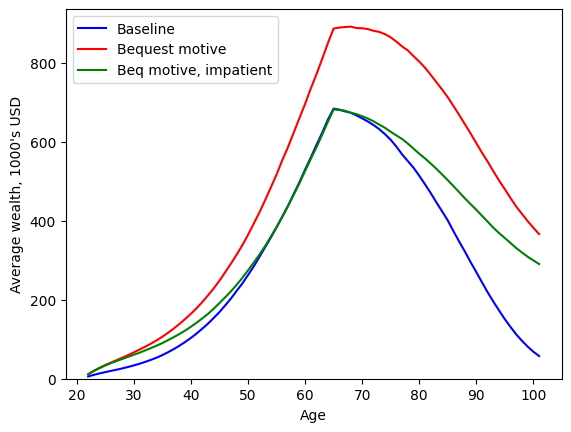

In [9]:
# Plot the three types' average wealth profiles
age_vec = np.arange(22, 102)
plt.plot(age_vec, A_base, "-b")
plt.plot(age_vec, A_bequest, "-r")
plt.plot(age_vec, A_impatient, "-g")
plt.legend(["Baseline", "Bequest motive", "Beq motive, impatient"], loc=2)
plt.xlabel("Age")
plt.ylabel("Average wealth, 1000's USD")
plt.ylim(0.0, None)
plt.show()

This graph should familiar if you've looked at the notebook for `BequestWarmGlowConsumerType`. The agents want to hold more wealth in old age (i.e. not run down their wealth to zero), so they accumulate more wealth early in life to finance their desire to consume *and* hold wealth when old. When the discount factor is adjusted so that agents accumulate about the same amount at retirement as in the baseline, we see that they want to decumulate their wealth more slowly, with a positive target wealth ratio even as death becomes increasingly likely.

We can also plot the (aggregate) share of wealth held in the risky asset for each of the three models.

In [10]:
# Extract risky share profiles for all types
risky_assets_base = BaseType.hystory["Share"] * aLvl_base
risky_assets_bequest = BequestType.hystory["Share"] * aLvl_bequest
risky_assets_impatient = ImpatientType.hystory["Share"] * aLvl_impatient
S_base = np.mean(risky_assets_base, axis=1) / A_base
S_bequest = np.mean(risky_assets_bequest, axis=1) / A_bequest
S_impatient = np.mean(risky_assets_impatient, axis=1) / A_impatient

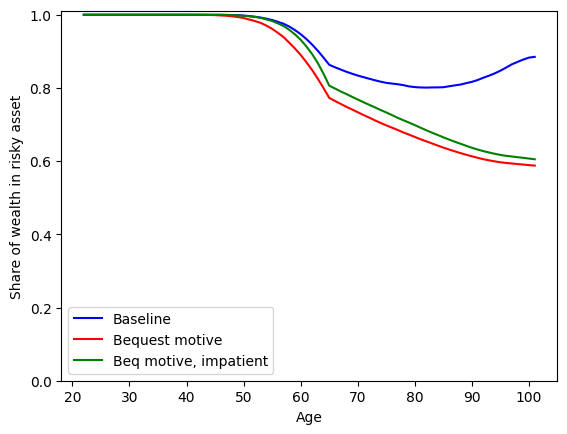

In [11]:
# Plot the three types' share of wealth held in the risky asset
age_vec = np.arange(22, 102)
plt.plot(age_vec, S_base, "-b")
plt.plot(age_vec, S_bequest, "-r")
plt.plot(age_vec, S_impatient, "-g")
plt.legend(["Baseline", "Bequest motive", "Beq motive, impatient"], loc=3)
plt.xlabel("Age")
plt.ylabel("Share of wealth in risky asset")
plt.ylim(0.0, 1.01)
plt.show()

The optimal risky asset share is non-increasing in wealth, so agents with a bequest motive (who run up more wealth) will tend to put a smaller share of that wealth into the risky asset. Early in life, all three types of agent hold (nearly) all of their wealth in the risky asset, as they have many future periods for the higher risky returns to accumulate and "smooth out" the ups and downs of the market. As retirement approaches, the agents anticipate that a large share of their consumption will be financed through their wealth holdings, and they begin to scale back their risky investments to reduce future consumption fluctuations. This pattern continues through retirement *except* for the baseline agents, who run their wealth down so far that the downward slope of the risky share function (w.r.t. wealth) overcomes the prudence effect of consuming from wealth, and they *increase* their risky allocation late in life.